<a href="https://colab.research.google.com/github/Leela-Battu/Netflix-Titles-analysis.-/blob/main/Netflix_Titles_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Mount your Google Drive to access files in Colab
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
missing_values=df.isnull().sum()

In [ ]:
[features for features in df.columns if df[features].isnull().sum()>0]

['director', 'cast', 'country', 'date_added', 'rating', 'duration']

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
print(missing_values)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df['director'].fillna('No director',inplace=True)
df['cast'].fillna('No cast',inplace=True)
df['country'].fillna('No country',inplace=True)
df['date_added']=df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
# Check if 'duration' is in the DataFrame's columns
if 'duration' in df.columns:
    df.drop('duration',axis=1,inplace=True)
else:
    print("Column 'duration' not found in DataFrame.")

/tmp/ipykernel_16524/4007303945.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('No director',inplace=True)
/tmp/ipykernel_16524/4007303945.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
for col in df.columns:
    if df[col].dtype in ['object']:
        df[col].fillna(df[col].mode().iloc[0],inplace=True)

/tmp/ipykernel_16524/2999007360.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode().iloc[0],inplace=True)


In [ ]:
missing_values=df.isnull().sum()
print(missing_values)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
listed_in       0
description     0
dtype: int64


In [ ]:
missing_values=df.notnull().sum()
print(missing_values)

show_id         8807
type            8807
title           8807
director        8807
cast            8807
country         8807
date_added      8807
release_year    8807
rating          8807
listed_in       8807
description     8807
dtype: int64


In [ ]:
df.to_csv('netflix_cleaned_data')

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,No director,No cast,No country,"July 1, 2019",2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.shape

(8807, 11)

In [ ]:
df.size

96877

<Axes: >

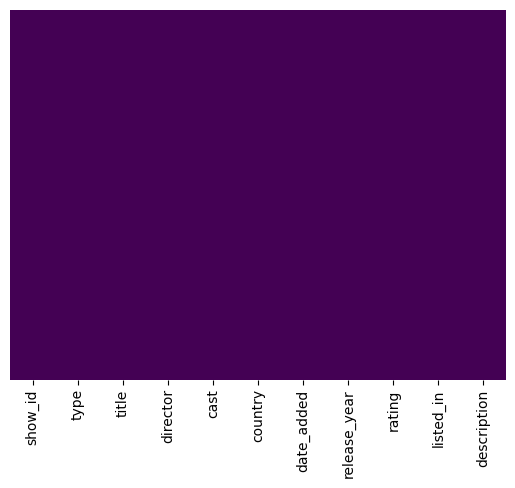

In [ ]:
 sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df.country.value_counts()

,count
country,
United States,2818
India,972
No country,831
United Kingdom,419
Japan,245
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


In [ ]:
country_names=df.country.value_counts().index
country_names

Index(['United States', 'India', 'No country', 'United Kingdom', 'Japan',
       'South Korea', 'Canada', 'Spain', 'France', 'Mexico',
       ...
       'United States, Venezuela', 'Germany, United States, Italy',
       'United Kingdom, Australia, Canada, United States',
       'New Zealand, United Kingdom, Australia',
       'Ireland, Canada, United States, United Kingdom',
       'Germany, Canada, United States',
       'Denmark, United Kingdom, South Africa, Sweden, Belgium',
       'Serbia, South Korea, Slovenia', 'United Kingdom, Spain, Belgium',
       'South Africa, United States, Japan'],
      dtype='object', name='country', length=749)

In [ ]:
country_val= df.country.value_counts().values

In [ ]:
df.country.value_counts().head(10)

,count
country,
United States,2818
India,972
No country,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
rating_val=df.rating.value_counts().index

([<matplotlib.patches.Wedge at 0x792b0f9f3410>,
 [Text(0.5894889189327136, 0.9287102963010266, 'United States'),
  Text(-0.7785802003139449, 0.7770539696051348, 'India'),
  Text(-1.0890434629449726, 0.15486876966264784, 'No country'),
  Text(-1.0493520223234596, -0.3299398933831219, 'United Kingdom'),
  Text(-0.9426334418991632, -0.566958723553432, 'Japan'),
  Text(-0.8414143282094991, -0.70853505790734, 'South Korea'),
  Text(-0.737946504501182, -0.8157419668586919, 'Canada'),
  Text(-0.6383143831025163, -0.8958542003721667, 'Spain'),
  Text(-0.549546486761952, -0.9528896362578386, 'France'),
  Text(-0.4681865240147326, -0.9953900636087354, 'Mexico'),
  Text(-0.390177822734953, -1.028475214405195, 'Egypt'),
  Text(-0.3117356349235575, -1.0549032628249884, 'Turkey'),
  Text(-0.2357465542459963, -1.0744410463869758, 'Nigeria'),
  Text(-0.16554367606909684, -1.087471972656551, 'Australia'),
  Text(-0.10011502494700916, -1.0954346086279454, 'Taiwan'),
  Text(-0.03746451125419832, -1.09936

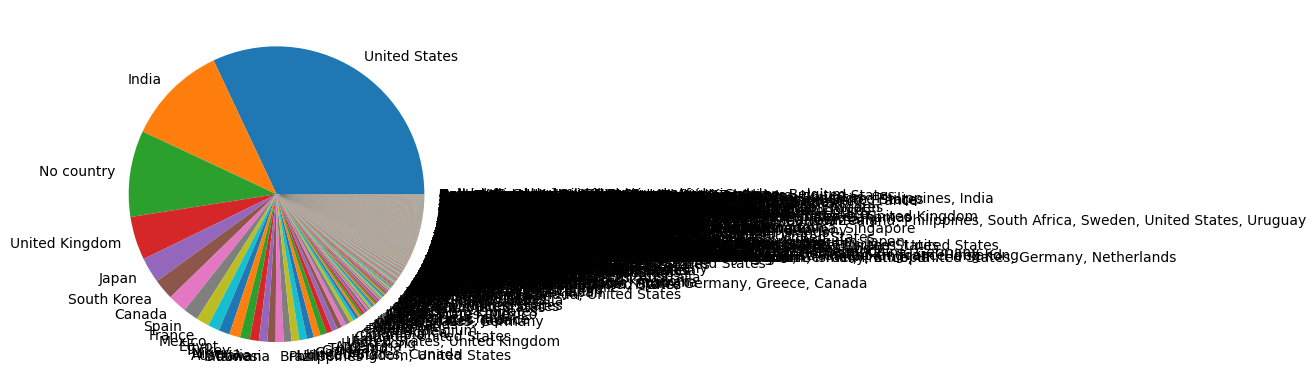

In [ ]:
plt.pie(country_val,labels=country_names)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.groupby(['title','release_year','rating']).size()

,,,0
title,release_year,rating,
#Alive,2020,TV-MA,1
#AnneFrank - Parallel Stories,2019,TV-14,1
#FriendButMarried,2018,TV-G,1
#FriendButMarried 2,2020,TV-G,1
#Roxy,2018,TV-14,1
...,...,...,...
忍者ハットリくん,2012,TV-Y7,1
海的儿子,2016,TV-14,1
마녀사냥,2015,TV-MA,1


In [ ]:
result=df.groupby(['title','release_year','rating']).size()
reset_df=result.reset_index(name="ratingcount")

/tmp/ipykernel_16524/1070324857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='release_year',y='ratingcount',data=reset_df,palette=['skyblue','grey','green'])
/tmp/ipykernel_16524/1070324857.py:3: UserWarning: 
The palette list has fewer values (3) than needed (74) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='release_year',y='ratingcount',data=reset_df,palette=['skyblue','grey','green'])


<Axes: xlabel='release_year', ylabel='ratingcount'>

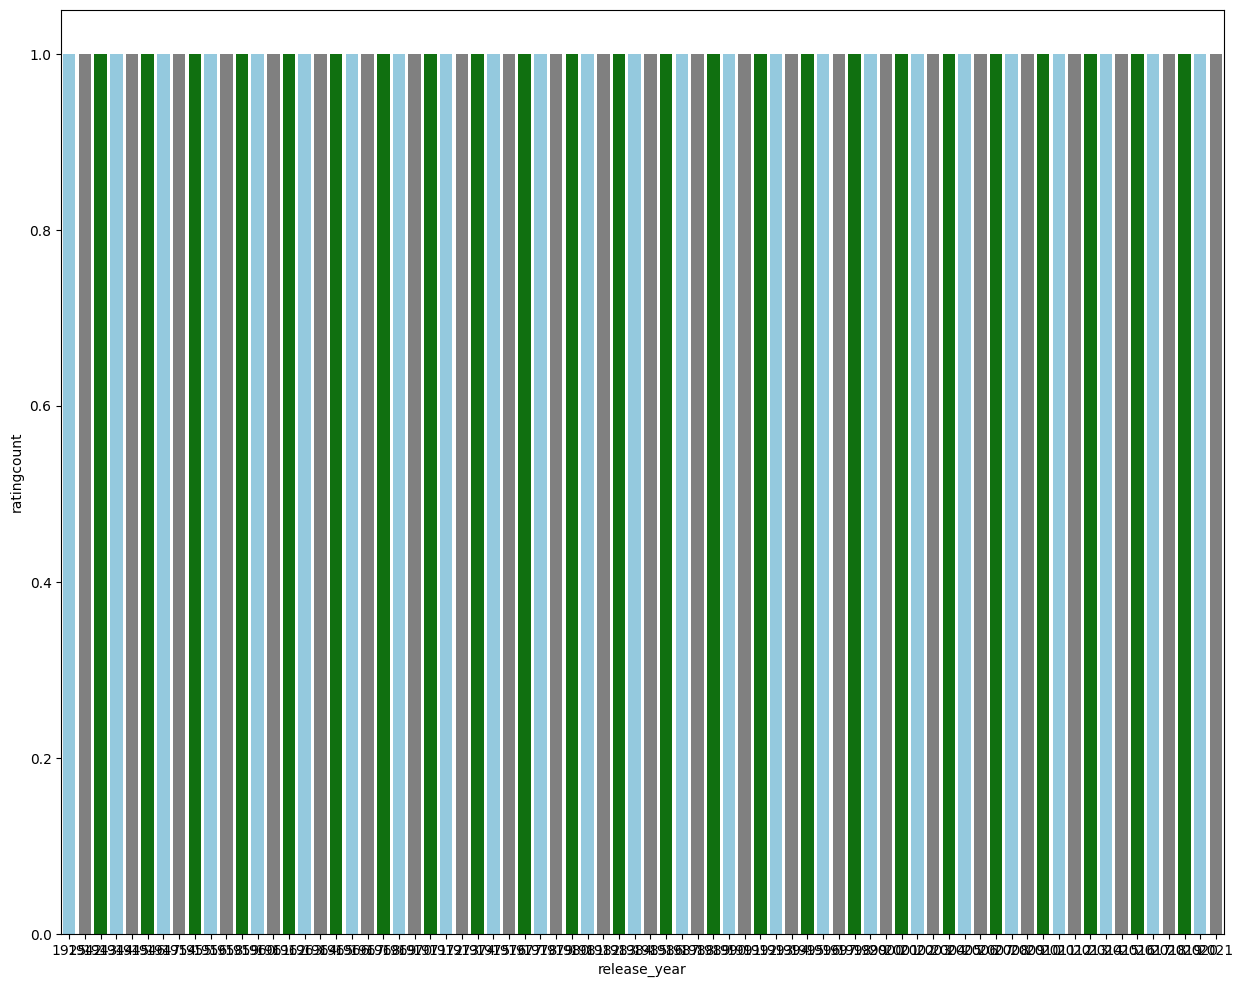

In [ ]:
import matplotlib
matplotlib.rcParams['figure.figsize']=(15,12)
sns.barplot(x='release_year',y='ratingcount',data=reset_df,palette=['skyblue','grey','green'])

In [ ]:
rating_values=df.rating.value_counts().values

In [ ]:
rating_values=df.rating.value_counts().index

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,No director,No cast,No country,"July 1, 2019",2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


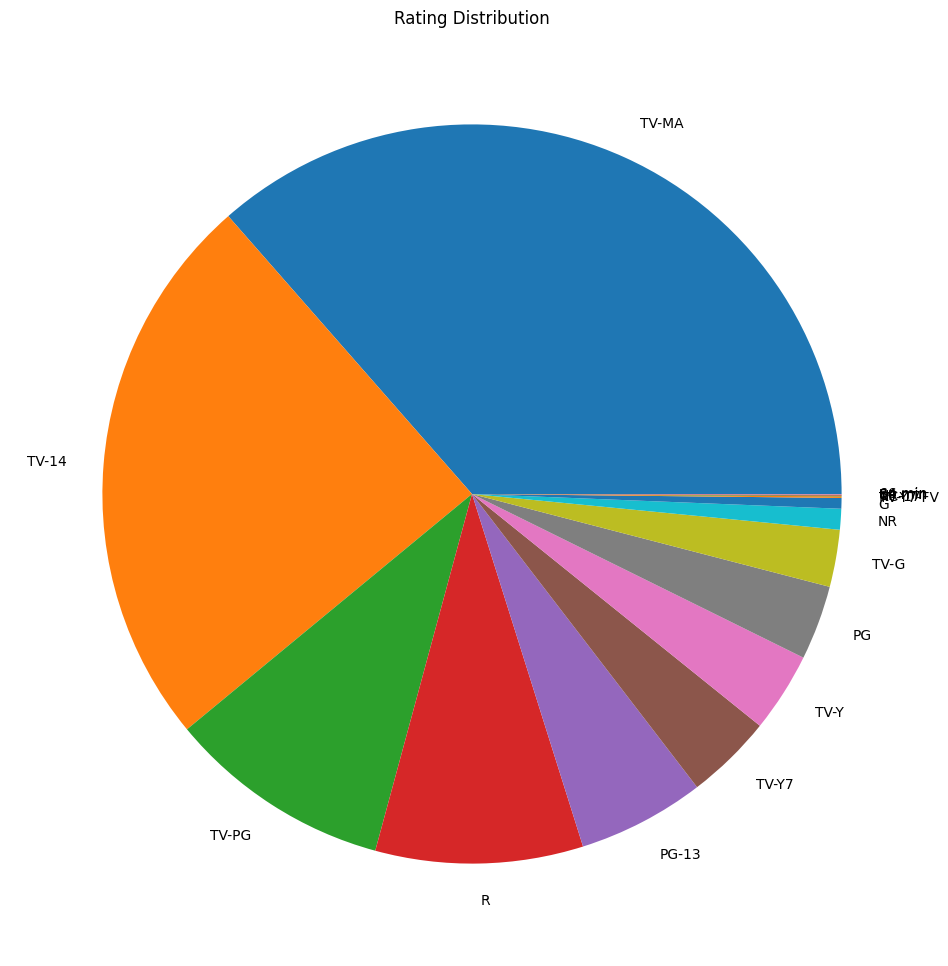

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
rating_counts=df['rating'].value_counts()
plt.pie(rating_counts.values,labels=rating_counts.index)
plt.title('Rating Distribution')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
lable_encoder=LabelEncoder()

In [ ]:
df['rating']=lable_encoder.fit_transform(df['rating'])
df.head(100)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020,7,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,11,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021,11,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021,11,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,11,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
95,s96,TV Show,The Circle,No director,Michelle Buteau,"United States, United Kingdom","September 8, 2021",2021,11,Reality TV,Status and strategy collide in this social exp...
96,s97,Movie,If I Leave Here Tomorrow: A Film About Lynyrd ...,Stephen Kijak,"Ronnie Van Zandt, Gary Rossington, Allen Colli...",United States,"September 7, 2021",2018,11,"Documentaries, Music & Musicals","Using interviews and archival footage, this do..."
97,s98,TV Show,Kid Cosmic,No director,"Jack Fisher, Tom Kenny, Amanda C. Miller, Kim ...",United States,"September 7, 2021",2021,14,"Kids' TV, TV Comedies, TV Sci-Fi & Fantasy",A boy's superhero dreams come true when he fin...
98,s99,TV Show,Octonauts: Above & Beyond,No director,"Antonio Aakeel, Chipo Chung, Simon Foster, Ter...",United Kingdom,"September 7, 2021",2021,13,"British TV Shows, Kids' TV",The Octonauts expand their exploration beyond ...


In [ ]:
df['rating']=lable_encoder.fit_transform(df['rating'])
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020,7,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,11,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021,11,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021,11,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,11,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",No country,"September 24, 2021",2021,11,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",No country,"September 24, 2021",2021,6,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,11,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,9,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,7,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder=OneHotEncoder()

In [ ]:
one_hot_encoder=OneHotEncoder()
df['rating']=one_hot_encoder.fit_transform(df[['rating']]).toarray()
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020,0.0,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,0.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021,0.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021,0.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,0.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",No country,"September 24, 2021",2021,0.0,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",No country,"September 24, 2021",2021,0.0,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,0.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,0.0,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,0.0,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
plt.figure(figsize=(12,4))
ax=sns.countplot(df.rating,palette='inferno')
for p in ax.patches:
  ax.annotate('{:0.0f}'.format(p.get_height()),(p.get_x(),p.get_height()))
  plt.title('Movie Ratings',fontsize=22,fontweight='bold')
  plt.xticks(rotation=80)

/tmp/ipykernel_16524/2342216523.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(df.rating,palette='inferno')


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df['type'].value_counts().plot(kind='pie', explode=(0.25,0.025),colors=['purple','red'],autopct='%1.1f%%')
plt.title('Ratio of Movie to TV show ')
plt.show()

In [ ]:
df.type.value_counts()

In [ ]:
plt.figure(figsize=(5,1))
ax=sns.countplot(df.type,palette='Accent_r')
for p in ax.patches:
  ax.annotate('{:0.0f}'.format(p.get_height()),(p.get_x()+0.25,p.get_height()))
  plt.title('Count of movie and TV show')
  plt.ylabel('Total Counts')

In [ ]:
replace_structure = {
    'PG-13': 'TEENS',
    'PG-14': 'TEENS',
    'TV-MA': 'ADULTS',
    'PG': 'KIDS WITH GUIDANCE',
    'TV-14': 'TEENS',
    'TV-PG': 'KIDS WITH GUIDANCE',
    'TV-G': 'KIDS',
    'NC-17': 'ADULTS',
    'TV-Y': 'KIDS'
}
df['rating'] = df['rating'].replace(replace_structure)

In [ ]:
plt.figure(figsize=(6,6))
# Count the number of unique ratings after replacement
num_ratings = df['rating'].value_counts().size
df['rating'].value_counts().plot(kind='pie',autopct='%1.f%%',
                                 explode=tuple([0.03] * num_ratings)) # Adjust explode to match
plt.title('Ratings of Netflix titles',fontsize=22,fontweight='bold')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and it has 'rating' and 'type' columns

# Create the countplot
ax = sns.countplot(x='rating', hue='type', palette='Blues', data=df)

# Annotate the bars
for p in ax.patches:
    ax.annotate('{:0.0f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.show()



In [ ]:
from wordcloud import WordCloud
plt.figure(figsize=(10,6))
wordcloud=WordCloud(background_color='black',width=1500,height=1000)
wordcloud.generate("".join(df.title))
plt.imshow(wordcloud)
plt.title('common words in Netflix title',fontsize=22,fontweight='bold')
plt.axis('off')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Assuming df is your DataFrame and it has a 'cast' column

# Convert NaN values to empty strings and join the cast column into a single string
director_text = " ".join(df.cast.fillna('').astype(str))

# Create the word cloud
wordcloud = WordCloud(background_color='white', width=1500, height=1000).generate(director_text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.title('Most Common  director Names', fontsize=22, fontweight='bold')
plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
wordcloud=WordCloud(background_color='white',width=1500,height=1000)

# Convert the 'cast' column to strings, handling potential missing values
cast_text = " ".join(df['cast'].astype(str).fillna(''))
wordcloud.generate(cast_text.replace('cast',''))

plt.imshow(wordcloud)
plt.title('Most common Actor Name',fontsize=22,fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
df['release_year'].value_counts().sort_index()

In [ ]:
df['release_year'].value_counts().plot(kind='bar',figsize=(16,5),title='New Release per year')